(76000, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76000 entries, 0 to 75999
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Date                76000 non-null  datetime64[ns]
 1   Store ID            76000 non-null  object        
 2   Product ID          76000 non-null  object        
 3   Category            76000 non-null  object        
 4   Region              76000 non-null  object        
 5   Inventory Level     76000 non-null  int64         
 6   Units Sold          76000 non-null  int64         
 7   Units Ordered       76000 non-null  int64         
 8   Price               76000 non-null  float64       
 9   Discount            76000 non-null  int64         
 10  Weather Condition   76000 non-null  object        
 11  Promotion           76000 non-null  int64         
 12  Competitor Pricing  76000 non-null  float64       
 13  Seasonality         76000 non-null

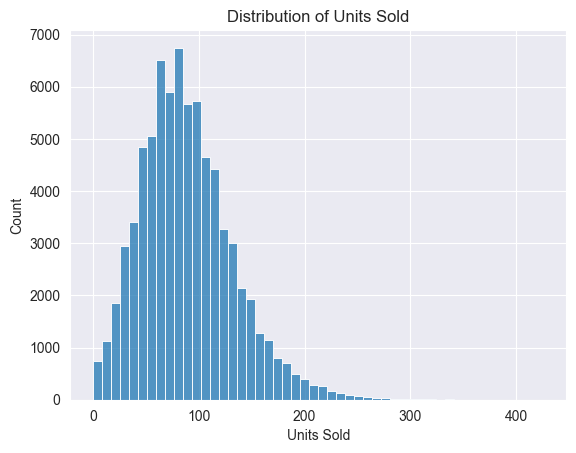

Available stores: ['S001' 'S002' 'S003' 'S004' 'S005']
Available products: ['P0001' 'P0002' 'P0003' 'P0004' 'P0005']


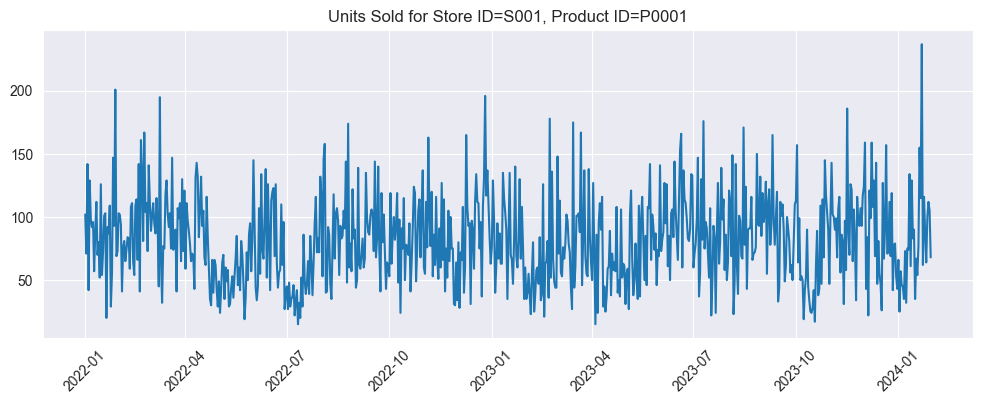

MAE naive lag1: 36.45
MAE Linear Regression: 32.82
Coefficients: {'dayofweek': np.float64(0.1574973804259786), 'month': np.float64(0.8058254372214675), 'Price': np.float64(-0.013992537833836352), 'Inventory Level': np.float64(0.0467885808030575)}


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
# Загрузка данных (обратите внимание: колонка называется "Date" с большой буквы)
df = pd.read_csv("../data/raw/demand_forecasting.csv", parse_dates=["Date"])
print(df.shape)
df.head()

# EDA: пропуски, типы, статистики
df.info()
df.describe()

# Распределение целевой переменной (Units Sold)
sns.histplot(df["Units Sold"], bins=50)
plt.title("Distribution of Units Sold")
plt.show()

# Продажи по дням для одного товара в одном магазине
# Выбираем store=1, product=29 (если такие есть, иначе первые попавшиеся)
# Проверим, какие store и product существуют
stores = df["Store ID"].unique()
products = df["Product ID"].unique()
print("Available stores:", stores[:5])
print("Available products:", products[:5])

# Возьмём первый store и первый product для примера
sample_store = stores[0]
sample_product = products[0]

sample = df[(df["Store ID"] == sample_store) & (df["Product ID"] == sample_product)].sort_values("Date")
plt.figure(figsize=(12,4))
plt.plot(sample["Date"], sample["Units Sold"])
plt.title(f"Units Sold for Store ID={sample_store}, Product ID={sample_product}")
plt.xticks(rotation=45)
plt.show()

# Простой baseline: предсказание предыдущего значения (lag1)
sample["lag1"] = sample["Units Sold"].shift(1)
sample_clean = sample.dropna()
mae_lag1 = mean_absolute_error(sample_clean["Units Sold"], sample_clean["lag1"])
print(f"MAE naive lag1: {mae_lag1:.2f}")

# Baseline с линейной регрессией на признаках даты и других числовых признаках
# Создадим копию df, чтобы не изменять исходный
df_baseline = df.copy()
df_baseline["dayofweek"] = df_baseline["Date"].dt.dayofweek
df_baseline["month"] = df_baseline["Date"].dt.month

# Доступные числовые признаки: Price, Inventory Level, Discount (если есть), возможно другие
features = ["dayofweek", "month", "Price", "Inventory Level"]
target = "Units Sold"

# Для временных рядов не перемешиваем — используем временной порядок
# Сортируем по дате перед сплитом
df_baseline = df_baseline.sort_values("Date")
split_idx = int(0.8 * len(df_baseline))
train = df_baseline.iloc[:split_idx]
test = df_baseline.iloc[split_idx:]

X_train, y_train = train[features], train[target]
X_test, y_test = test[features], test[target]

lr = LinearRegression()
lr.fit(X_train, y_train)
preds = lr.predict(X_test)
mae_lr = mean_absolute_error(y_test, preds)
print(f"MAE Linear Regression: {mae_lr:.2f}")

# Дополнительно: вывод коэффициентов модели
print("Coefficients:", dict(zip(features, lr.coef_)))